In [ ]:
# 웹이랑 연결하면댐. 

%matplotlib inline
import sys, importlib
sys.path.insert(0, '.')
import functions; importlib.reload(functions)
from functions import fetch_4h, detect, chart

In [ ]:
# ============================================================
# 설정
# ============================================================
TICKER = "^NDX"          # 종목 (^NDX=나스닥100, QQQ=ETF, NQ=F=선물)
FETCH_DAYS = 730         # 데이터 수집 기간 (일)
RSI_PERIOD = 14          # RSI 계산 기간
LB_LEFT = 5              # 피봇 좌측 확인 봉수
LB_RIGHT = 2             # 피봇 우측 확인 봉수 (확정 지연 = LB_RIGHT × 4h)
RANGE_LOWER = 5          # 피봇 간 최소 간격 (봉)
RANGE_UPPER = 60         # 피봇 간 최대 간격 (봉)
LOOKBACK = 2             # 이전 N개 피봇까지 비교 (1=직전만, 2=1개 건너뜀 허용)
CHART_BARS = 200         # 차트에 표시할 최근 봉 수

In [22]:
# 데이터 수집 (1h → 장중 세션 4h)
df = fetch_4h(TICKER, FETCH_DAYS)
print(f"{len(df)}봉  |  {df.index[0].date()} ~ {df.index[-1].date()}  |  종가 ${df['close'].iloc[-1]:.2f}")

1450봉  |  2023-03-27 ~ 2026-02-23  |  종가 $24714.08


In [23]:
# 다이버전스 탐지
signals, rsi, pl, ph = detect(df, RSI_PERIOD, LB_LEFT, LB_RIGHT, RANGE_LOWER, RANGE_UPPER, LOOKBACK)
print(f"피봇: Low {len(pl)} / High {len(ph)}  |  시그널: {len(signals)}개")
for s in signals[-10:]:
    print(f"  [{s.label:6s}] {df.index[s.idx].strftime('%Y-%m-%d %H:%M')} | ${s.price:.2f} | RSI {s.rsi:.1f}")

피봇: Low 88 / High 87  |  시그널: 89개
  [Bear  ] 2025-10-02 13:30 | $24912.54 | RSI 70.8
  [H.Bull] 2025-10-10 13:30 | $24211.39 | RSI 36.9
  [Bear  ] 2025-10-20 09:30 | $25175.55 | RSI 62.2
  [H.Bull] 2025-10-22 09:30 | $24725.47 | RSI 48.2
  [H.Bull] 2025-11-07 09:30 | $24603.78 | RSI 35.9
  [Bear  ] 2025-11-10 13:30 | $25654.13 | RSI 53.7
  [Bear  ] 2025-12-10 13:30 | $25830.91 | RSI 64.2
  [H.Bull] 2025-12-17 13:30 | $24648.51 | RSI 33.0
  [Bear  ] 2026-01-12 09:30 | $25827.21 | RSI 61.8
  [Bull  ] 2026-02-12 13:30 | $24643.91 | RSI 36.9


/workspace/Quant/v03_종목추천/indicator_test_chart/functions/chart.py:143: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


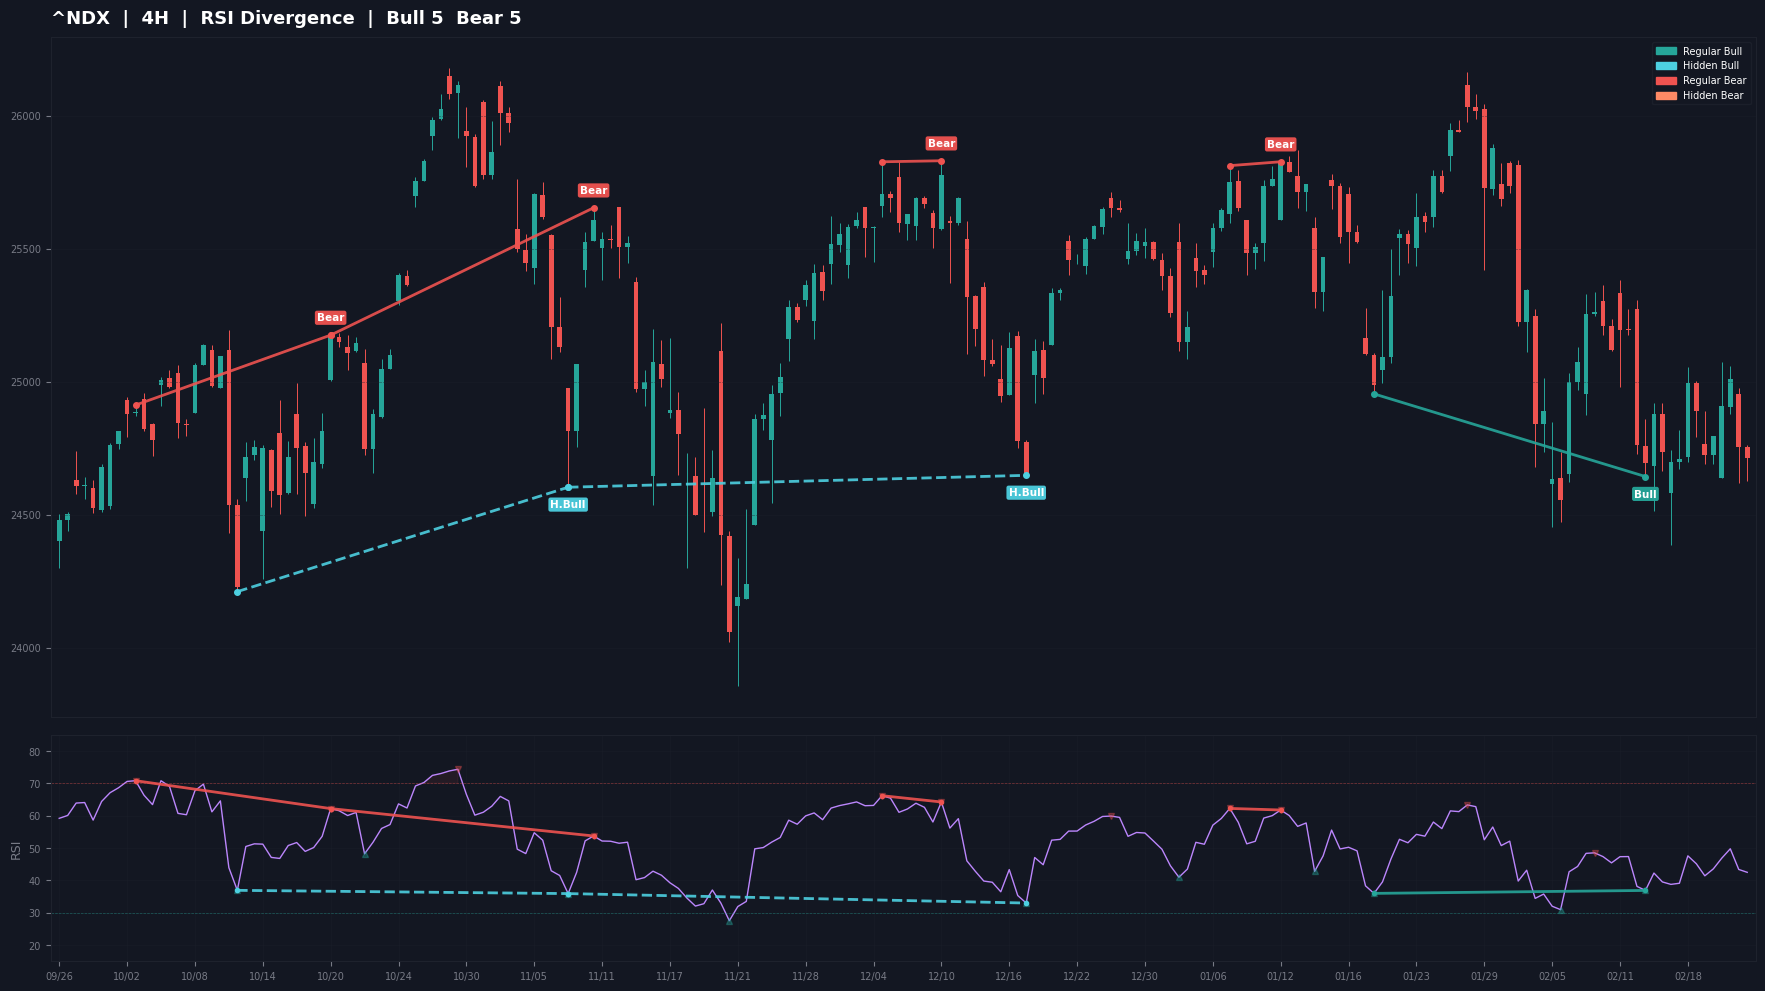

In [24]:
# 차트
chart(df, rsi, signals, pl, ph, TICKER, bars=CHART_BARS)

In [ ]:
# 넓은 범위
chart(df, rsi, signals, pl, ph, TICKER, bars=400)

In [ ]:
# 시그널 테이블
import pandas as pd
rows = []
for s in signals:
    pct = (df['close'].iloc[-1] - df['close'].iloc[s.idx]) / df['close'].iloc[s.idx] * 100
    rows.append({"Type": s.label, "Date": df.index[s.idx].strftime('%Y-%m-%d %H:%M'),
                 "Price": f"${s.price:.2f}", "RSI": f"{s.rsi:.1f}", "Since": f"{pct:+.1f}%"})
pd.DataFrame(rows)